## Implement a L-layer neural network
parameters: 
$$
W_1, b_1, W_2, b_2, ..., W_L, b_L
$$

hyperparameters: 
- learning rate
- number of iterations
- number of hidden layers (L)
- number of hidden units ($n_1, n_2, ..., n_L$)
- activation function in each layer

In [1]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage
from dnn_app_utils_v3 import *
from public_tests import *
from numpy import linalg as LA

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

### Summary of learning process
- initialize parameters
- compute loss using forward function (store A, Z when forwarding)
- by doing back propagation, compute gradients of parameters with respect to calculated loss (using A,Z stored in forward propagation and params)
- compute cost function
- update parameters according to gradients calculated in back propagation (gradien descent)
- repeat steps 2 to 5 for the number of iterations

In [44]:
class DeepNN:
    
    def __init__(self, layer_dims, actv_funcs):
        
        self.layer_dims = layer_dims
        self.L = len(self.layer_dims) # number of layers
        self.actv_funcs = actv_funcs # len = L-1

        assert not len(actv_funcs)>(self.L-1), "Too many activation function is given."
        assert not len(actv_funcs)<(self.L-1), "Too few activation function is given."
        assert not self.layer_dims[self.L-1]!=1, "This network only supports single layer output."
        
        self.params = self.create_parameters()     
        self.costs = []
        
    def create_parameters(self): 
        params = {}
        for l in range(1, self.L):
            params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            params["b"+str(l)] = np.zeros((self.layer_dims[l], 1))
            print("W", l, " shape: ", params["W"+str(l)].shape)
            print("b", l, " shape: ", params["b"+str(l)].shape)

        return params

    def forward(self, X):
        linear_actvs = {}
        # X.shape should be (layer_dim[0], m)
        # m = #training examples
        linear_actvs["A0"] = X

        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            if l!=self.L-1:
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = "relu")
            else:
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = "sigmoid")

        return linear_actvs
        
    def backward(self, Y, linear_actvs, loss_func="add later"):
        grads = {}
        m = Y.shape[1]
        
        # dA[L-1] = -Y / A_L-1 + (1-Y) / (1-A_L-1)
        grads["dA"+str(self.L-1)] = np.divide(-Y, linear_actvs["A"+str(self.L-1)]) + np.divide(1-Y, 1 - linear_actvs["A"+str(self.L-1)])
        # dZ[L-1] = dA[L-1] * G`
        grads["dZ"+str(self.L-1)] = np.multiply(grads["dA"+str(self.L-1)], self.act_func(linear_actvs["Z"+str(self.L-1)], func=self.actv_funcs[self.L-2], grad=True))

        # from l = L to l = 1
        for l in range(self.L-1, 0, -1):
            # dW[l] = 1/m * dZ[l] . A[l-1] + lambda/m * W[l]
            grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T) + ((self.reg_param/m) * self.params["W"+str(l)])
            # db[l] = 1/m * np sum (dZ_l)
            grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
            if l!=1:
                # dA[l-1] = (W[l]).T . dZ[l]
                grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                # dZ[l-1] = dA[l-1] * g`
                grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-1], grad=True))

        return grads
    
    def compute_cost(self, Y, linear_actvs, is_debug=False):
        m = Y.shape[1]
        AL = linear_actvs["A"+str(self.L-1)]

        cost = -1/m * (np.sum(np.multiply(Y, np.log(AL))) + np.sum(np.multiply((1-Y), np.log(1-AL)))) 
        reg_cost = 0
        for l in range(self.L-1, 0, -1):
            reg_cost += np.sum(np.square(self.params['W'+str(l)]))

        cost = cost + self.reg_param/(2*m) * reg_cost
        cost = np.squeeze(cost)

        return cost

    def update_params(self, grads, lr):
        for l in range(1, self.L):
            self.params["W"+str(l)] = self.params["W"+str(l)] - lr * grads["dW"+str(l)]
            self.params["b"+str(l)] = self.params["b"+str(l)] - lr * grads["db"+str(l)]
                
    def train(self, X, Y, num_iterations, lr, reg_param = 0, is_debug=False):
        self.reg_param = reg_param
        self.learning_rate = lr
        m = X.shape[1] # ?
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not X.shape[1]!=Y.shape[1], "Number of inputs and outputs doesnt match."
        assert not Y.shape[0]!= 1, "This network only supports single output."
        
        for i in range(num_iterations):
            linear_actvs = self.forward(X)
            grads = self.backward(Y, linear_actvs)
            cost = self.compute_cost(Y, linear_actvs, is_debug)
            self.update_params(grads, lr)
            
            if i % 100 == 0 or i == num_iterations-1:
               print("cost after iteration ", i, ": ", cost)
        
            if i % 40 == 0 or i == num_iterations-1:
                self.costs.append(cost)
                
        #return params

    def predict(self, X, y):
        assert not X.shape[1]!=y.shape[1], "Number of inputs and outputs doesnt match."
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not y.shape[0]!=1, "This network only supports single layer output."

        m = X.shape[1]
        n = len(self.params) // 2 
        p = np.zeros((1,m))
        
        linear_actvs = self.forward(X)
        yhat = linear_actvs["A"+str(n)]

        for i in range(0, yhat.shape[1]):
            if yhat[0,i] > 0.5:
                p[0,i] = 1
            else:
                p[0,i] = 0
    
        print("Accuracy: "  + str(np.sum((p == y)/m)))

        return p
    
    def act_func(self, Z, func = "relu", grad=False):
        if func == "relu":
            if grad==False:
                return np.maximum(Z, 0)
            else:
                return np.where(Z <= 0, 0, 1)
            
        elif func == "sigmoid":
            if grad==False:
                return 1/(1+np.exp(-Z))
            else: 
                s = 1/(1+np.exp(-Z))
                return s * (1-s)
        else:
            assert False, "Activation function "+func+" is not supported."

# Training on CAT dataset

y = 0. It's a non-cat picture.


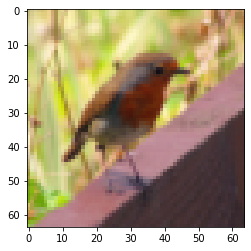

In [45]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()
# Example of a picture
index = 10
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

In [46]:
# Explore your dataset 
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


In [47]:
# Reshape the training and test examples 
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


In [ ]:
activation_funcs = ["relu", "relu", "relu", "sigmoid"]
dnn = DeepNN([12288, 20, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 2500, 0.0075)

In [ ]:
# Plot learning curve (with costs)
costs = np.squeeze(dnn.costs)
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(dnn.learning_rate))
plt.show()

In [31]:
pred_train = dnn.predict(train_x, train_y)

Accuracy: 0.9999999999999998


In [32]:
pred_test = dnn.predict(test_x, test_y)

Accuracy: 0.76


W 1  shape:  (20, 12288)
b 1  shape:  (20, 1)
W 2  shape:  (10, 20)
b 2  shape:  (10, 1)
W 3  shape:  (5, 10)
b 3  shape:  (5, 1)
W 4  shape:  (1, 5)
b 4  shape:  (1, 1)
cost after iteration  0 :  0.8339526821911618
cost after iteration  100 :  0.7677553690851804
cost after iteration  200 :  0.7510941057505531
cost after iteration  300 :  0.7361339616902165
cost after iteration  400 :  0.7278304099296611
cost after iteration  500 :  0.720937340438304
cost after iteration  600 :  0.7122382444784487
cost after iteration  700 :  0.6985254652693478
cost after iteration  800 :  0.6760923685131311
cost after iteration  900 :  0.6515965978417253
cost after iteration  1000 :  0.6271889234946767
cost after iteration  1100 :  0.6020339789532968
cost after iteration  1200 :  0.5734327024743365
cost after iteration  1300 :  0.5452183982991451
cost after iteration  1400 :  0.5148528464605429
cost after iteration  1500 :  0.48380910144721134
cost after iteration  1600 :  0.4531887537371034
cost afte

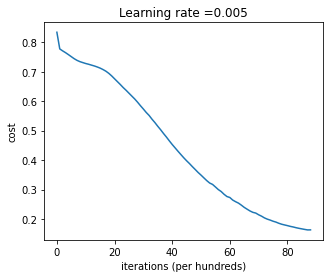

In [79]:
activation_funcs = ["relu", "relu", "relu", "sigmoid"]
dnn = DeepNN([12288, 20, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 3500, 0.0050, reg_param=1)

# Plot learning curve (with costs)
costs = np.squeeze(dnn.costs)
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(dnn.learning_rate))
plt.show()

In [80]:
pred_train = dnn.predict(train_x, train_y)

Accuracy: 0.9952153110047844


In [81]:
pred_test = dnn.predict(test_x, test_y)

Accuracy: 0.76
